# Kinetic Profiles from Paired VEST Diagnostics

## Build shot 48224 at 300 ms

The stored ODS sample `vaft/data/kineticEfit/ods_48224_300ms.json` is loaded when
present so the notebook runs offline; otherwise the profiles are rebuilt from the
paired Thomson-scattering and ion-Doppler diagnostics. The rebuild uses a different
equilibrium-mapping route than the stored sample (see the comment in the cell below),
so it approximates rather than reproduces the reference numbers.

loaded stored sample: ods_48224_300ms.json


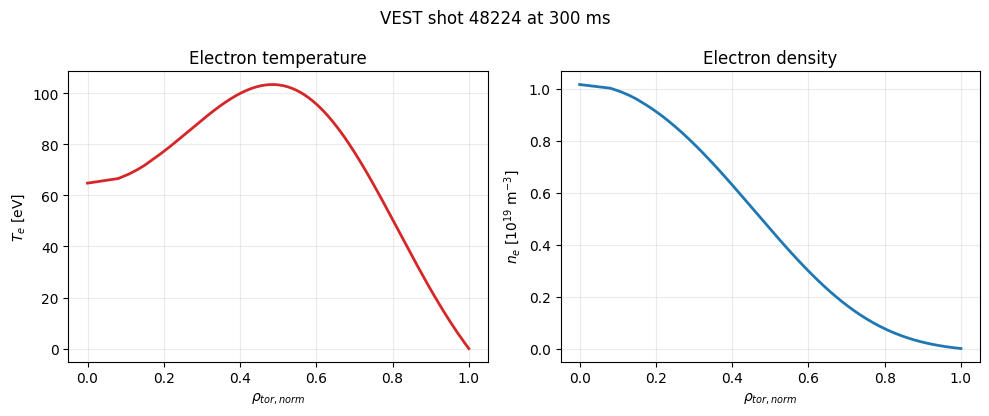

{'shot': 48224, 'time_ms': 300.0, 'grid_points': 129}


In [ ]:
from pathlib import Path
import os

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Select the rendering backend explicitly. In a Jupyter kernel (Jupyter Lab,
# VS Code) ask for the inline backend rather than relying on ipykernel to
# preset MPLBACKEND, which older releases do not do. With no IPython at all
# (a plain `python` run) fall back to headless Agg -- export MPLBACKEND,
# e.g. MPLBACKEND=macosx, to get windows from a script instead.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
from omas import ODS
from vaft.data.resources import data_path

data_root = data_path("kineticEfit")
sample = data_root / "ods_48224_300ms.json"

if sample.exists():
    # Offline path: the canonical kinetic-profile sample checked into vaft/data.
    # shot and time come from the sample itself -- they are not free parameters here.
    ods = ODS()
    ods.load(str(sample), consistency_check=False)
    shot = int(ods["dataset_description.data_entry.pulse"])
    time_ms = float(np.asarray(ods["core_profiles.time"], dtype=float)[0]) * 1e3
    print(f"loaded stored sample: {sample.name}")
else:
    # Fallback: rebuild from the paired raw diagnostics. This maps the
    # diagnostics onto the equilibrium with vaft's own psi interpolation
    # (vaft.data.read_geqdsk), whereas the stored sample was generated through
    # OMFIT's `fluxSurfaces`; the two agree to ~2% on the core values, so this
    # path reproduces the reference only approximately. See
    # vaft/data/README.md for the exact recipe.
    from vaft.code.efit import build_kinetic_core_profiles
    from vaft.data import read_geqdsk
    from vaft.machine_mapping.charge_exchange import charge_exchange
    from vaft.machine_mapping.dataset_description import dataset_description
    from vaft.machine_mapping.thomson_scattering import thomson_scattering

    shot = 48224
    time_ms = 300.0
    geq = read_geqdsk(data_root / "g048224.00300")
    ods = geq.to_omas()
    dataset_description(
        ods, source=shot,
        options={"source_type": "shot", "description": "Paired documentation sample"},
    )
    thomson_scattering(ods, shot, data_root / "NeTe_48224.mat")
    charge_exchange(
        ods, shotnumber=shot, options="ids", mat_file=data_root / "IDS_48224.mat"
    )
    # require_thomson: this notebook plots Te and ne, so a silent ion-only fit
    # would only fail later, on the first electron-profile access.
    ods = build_kinetic_core_profiles(
        ods, geq, time_ms,
        te_mode="polynomial", ne_mode="polynomial",
        ti_mode="polynomial", vtor_mode="polynomial",
        require_thomson=True,
    )
    print("rebuilt core_profiles from raw diagnostics")

profile = ods["core_profiles.profiles_1d.0"]
rho = np.asarray(profile["grid.rho_tor_norm"], dtype=float)
te = np.asarray(profile["electrons.temperature"], dtype=float)
ne = np.asarray(profile["electrons.density"], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].plot(rho, te, color="tab:red", lw=2)
axes[0].set(xlabel=r"$\rho_{tor,norm}$", ylabel=r"$T_e$ [eV]", title="Electron temperature")
axes[1].plot(rho, ne / 1e19, color="tab:blue", lw=2)
axes[1].set(xlabel=r"$\rho_{tor,norm}$", ylabel=r"$n_e$ [$10^{19}$ m$^{-3}$]", title="Electron density")
for ax in axes:
    ax.grid(alpha=0.25)
fig.suptitle(f"VEST shot {shot} at {time_ms:g} ms")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "kinetic-profile.png", dpi=180, bbox_inches="tight")
plt.show()
print({"shot": shot, "time_ms": time_ms, "grid_points": int(rho.size)})